In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
N_SEGS = 12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5   

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels

print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    n = params.shape[0]
    out = np.full(n, -np.inf)
    for i in range(n):
        try:
            logm1, logm2, a_i, p0_i, e0_i = params[i]
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
            ]
            h_temp = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
            # per-mode templates, same mode groups the loglike selected
            hm_arr = loglike_obj._generate_selected_waveforms(theta, selected)
            out[i] = float(gwf.Sf(loglike_obj.signal, h_temp, hm_arr,
                                  N_seg=N_SEGS, common_tau=True))  # beta auto
        except Exception as exc:
            print(f"  [warn] sample {i} failed: {exc}")
    return out


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=5s, T=1.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [3]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris2_sf/int_1yr_sf12'


In [4]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [5]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [6]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.11184229,  0.13919552,  0.82448759,  0.84901052,  0.7429011 ],
        [ 0.13220267,  0.17682854,  0.91591329,  0.77905735,  0.66456808],
        [ 0.12028615,  0.16576907,  0.89421531,  0.81055207,  0.72602141],
        ...,
        [ 0.11831681,  0.0939541 ,  0.95417218,  0.74093963,  0.43672375],
        [ 0.04414476, -0.04078786,  0.89793756,  0.86876282,  0.37487356],
        [ 0.1023194 ,  0.10497475,  0.87858263,  0.82486738,  0.62504915]])]

In [7]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([1.63063322e+02, 2.25636426e-01, 6.03857381e+01, ...,
        1.10430235e+01,           -inf, 1.36941194e-01])]

In [8]:
sampler.now_covariances

[array([[ 0.00053138,  0.00060068,  0.00030269, -0.0011409 , -0.00036326],
        [ 0.00060068,  0.00175366,  0.00028156, -0.00023893, -0.00090828],
        [ 0.00030269,  0.00028156,  0.00420424, -0.00257939, -0.00158193],
        [-0.0011409 , -0.00023893, -0.00257939,  0.00437283,  0.00047682],
        [-0.00036326, -0.00090828, -0.00158193,  0.00047682,  0.00928805]])]

In [9]:
np.argmax(logden_list)

0

In [10]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.68947383, 0.86959776, 0.86889644, 9.54703157, 0.42287033]])

In [14]:
log_density(maxld_pt1)

array([16.30633225])

In [15]:
log_density([param_true])

array([24.71883154])

In [16]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [17]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

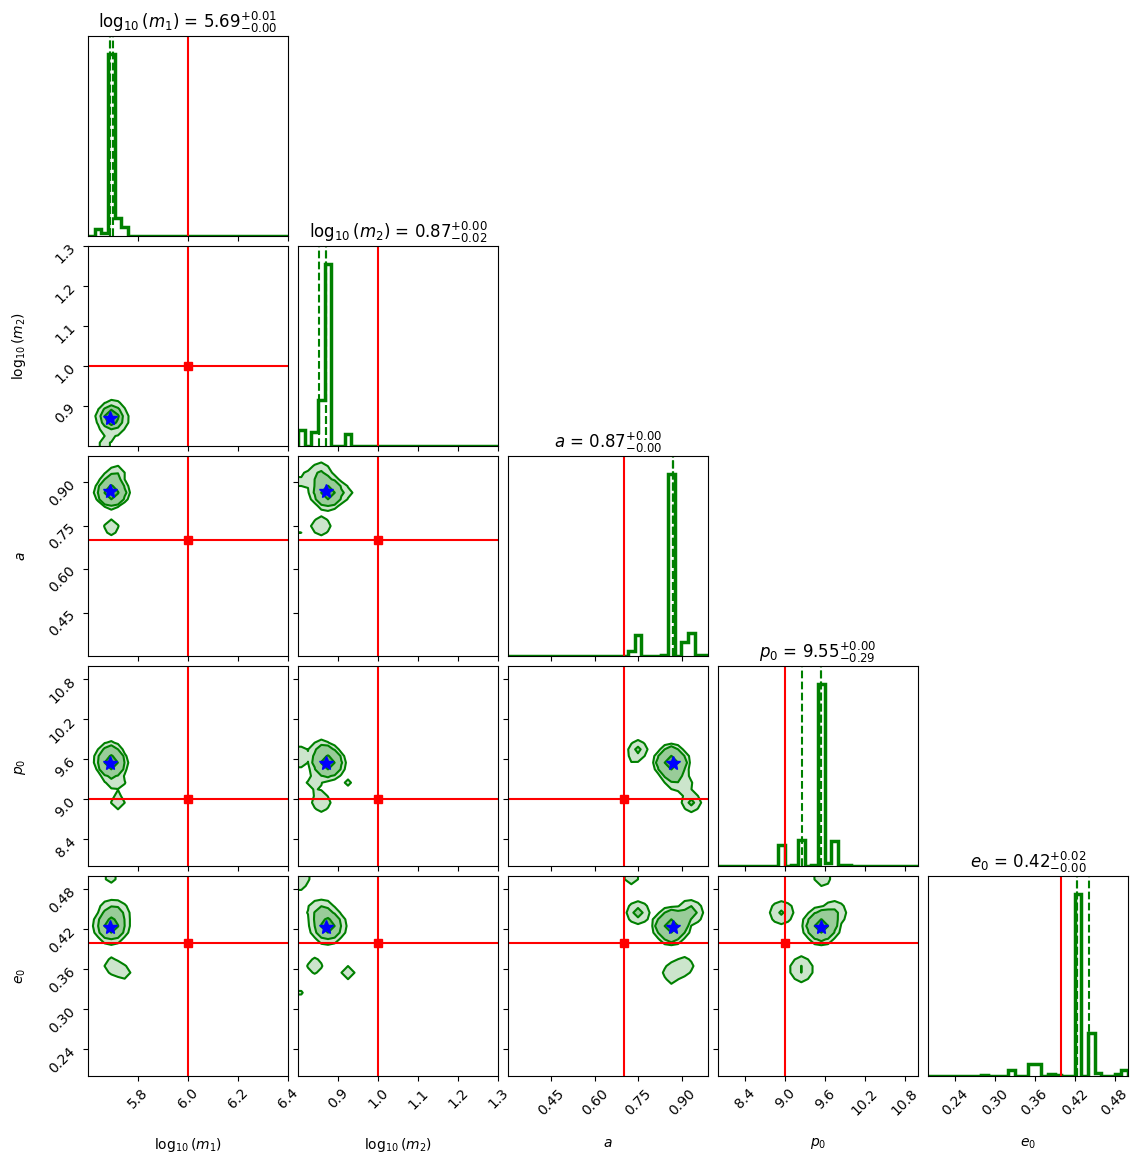

In [18]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [19]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

In [20]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [21]:
import matplotlib.pyplot as plt

# connection plot

In [22]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.68947383, 0.86959776, 0.86889644, 9.54703157, 0.42287033]])

In [23]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [24]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [25]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [26]:
logden_theory_proc1

array([16.30633225,  1.74950944,  3.54599406,  3.09309173,  4.32882195,
        3.59269185,  3.36418586,  4.29852611,  3.61036418,  4.38435537,
        4.09176398,  4.09597444,  4.45814063,  3.8230605 ,  4.56306943,
        4.39162741,  4.95866624,  4.37111754,  4.93232614,  4.43153306,
        4.80988244,  4.63306015,  4.86918761,  5.08719933,  4.74941505,
        5.28287132,  5.03627184,  4.94062579,  4.96895509,  6.01887667,
        5.74360627,  6.32108847,  5.91640894,  5.5050826 ,  6.37982046,
        6.61982097,  6.35892183,  6.12461526,  6.42686539,  7.0891256 ,
        6.70651984,  6.64105661,  6.68510722,  6.91102583,  7.30638891,
        7.13808346,  7.42347403,  8.33177927,  8.29758037, 24.71883154])

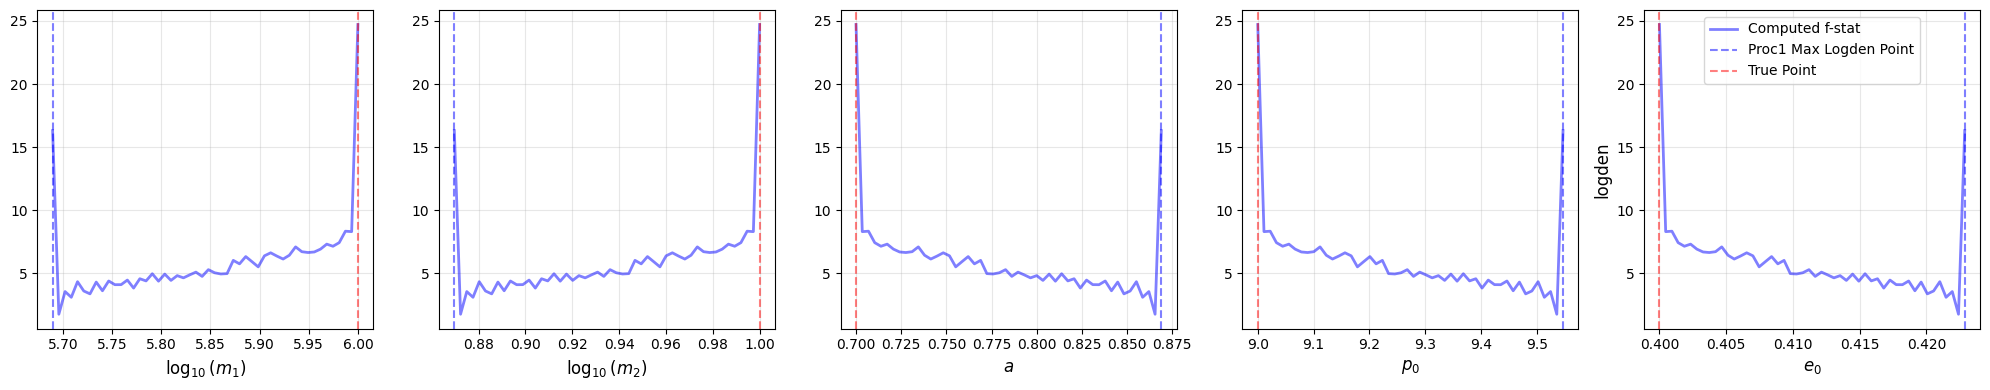

In [27]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [28]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [29]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [30]:
logden_tm = log_density(line_points_logm1.T)


  [warn] sample 0 failed: 
  [warn] sample 1 failed: 
  [warn] sample 2 failed: 
  [warn] sample 3 failed: 
  [warn] sample 4 failed: 
  [warn] sample 5 failed: 
  [warn] sample 6 failed: 
  [warn] sample 7 failed: 
  [warn] sample 8 failed: 
  [warn] sample 9 failed: 
  [warn] sample 10 failed: 
  [warn] sample 11 failed: 
  [warn] sample 12 failed: 
  [warn] sample 13 failed: 
  [warn] sample 14 failed: 
  [warn] sample 15 failed: 
  [warn] sample 16 failed: 
  [warn] sample 17 failed: 
  [warn] sample 18 failed: 
  [warn] sample 19 failed: 
  [warn] sample 20 failed: 
  [warn] sample 21 failed: 


KeyboardInterrupt: 

In [ ]:
logden_tm

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='f-stat (3mth) timemax')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()